#week07 / wine_pytorch

컴퓨터공학과 / 202433638 / 장영환

In [33]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from torchsummary import summary

import matplotlib.pyplot as plt

In [34]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/인공지능개론/week03/wine.csv')

In [35]:
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


<Axes: ylabel='count'>

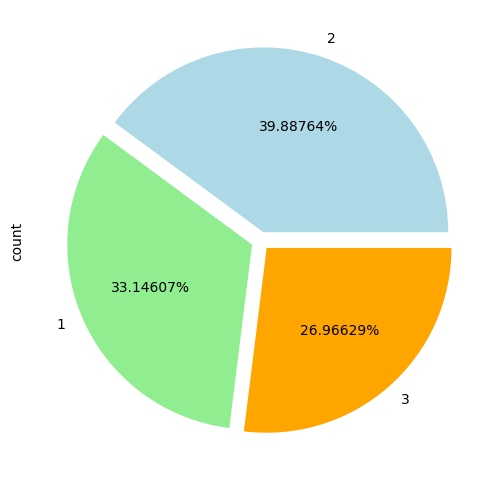

In [36]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size

data.Wine.value_counts().plot(kind='pie', autopct='%0.05f%%', colors=['lightblue', 'lightgreen', 'orange'], explode=(0.05, 0.05, 0.05))

In [37]:
data.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [38]:
# Wine 데이터 컬럼 확인용
# Wine은 타겟 클래스이고, 나머지 13개 컬럼은 연속형 수치 특성이다.
columns = ['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline']


In [39]:
# wine 데이터는 입력 특성이 연속형 수치 데이터이므로 입력 X에는 LabelEncoder를 적용하지 않는다.
# CrossEntropyLoss는 타겟 라벨이 0부터 시작해야 하므로 Wine 컬럼만 0, 1, 2로 인코딩한다.
label_encoder = LabelEncoder()
data['Wine'] = label_encoder.fit_transform(data['Wine'])

print('Wine class mapping:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


Wine class mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}


In [40]:
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,0,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,0,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,0,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,0,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,2,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,2,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,2,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,2,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [41]:
# 데이터와 타겟 분리
X = data.drop('Wine', axis=1).values
y = data['Wine'].values

In [42]:
# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [43]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape,

((142, 13), (36, 13), (142,), (36,))

In [44]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.int64)

In [45]:

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [46]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([142, 13]),
 torch.Size([36, 13]),
 torch.Size([142]),
 torch.Size([36]))

# 모델 정의

In [47]:
class WineDense(nn.Module):
    def __init__(self):
        super(WineDense, self).__init__()
        self.fc1 = nn.Linear(13, 64)  # wine 입력 특성 13개
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3)   # wine 클래스 3개

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)               # CrossEntropyLoss 사용 시 softmax를 따로 적용하지 않음
        return x

# Initialize the model, loss function, and optimizer
model = WineDense()


# 손실 함수 및 최적화 기법 정의

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 모델 학습

In [49]:
# Variables to store loss and accuracy
train_losses = []
test_accuracies = []

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss over an epoch
    train_losses.append(running_loss / len(train_dataloader))

    # Evaluate on test data
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")

Epoch 1/20, Loss: 1.0924, Accuracy: 36.11%
Epoch 2/20, Loss: 1.0413, Accuracy: 61.11%
Epoch 3/20, Loss: 0.9970, Accuracy: 75.00%
Epoch 4/20, Loss: 0.9405, Accuracy: 80.56%
Epoch 5/20, Loss: 0.8801, Accuracy: 86.11%
Epoch 6/20, Loss: 0.8192, Accuracy: 86.11%
Epoch 7/20, Loss: 0.7346, Accuracy: 86.11%
Epoch 8/20, Loss: 0.6569, Accuracy: 91.67%
Epoch 9/20, Loss: 0.5926, Accuracy: 91.67%
Epoch 10/20, Loss: 0.5287, Accuracy: 91.67%
Epoch 11/20, Loss: 0.4453, Accuracy: 91.67%
Epoch 12/20, Loss: 0.3802, Accuracy: 100.00%
Epoch 13/20, Loss: 0.3177, Accuracy: 100.00%
Epoch 14/20, Loss: 0.2695, Accuracy: 100.00%
Epoch 15/20, Loss: 0.2255, Accuracy: 100.00%
Epoch 16/20, Loss: 0.1947, Accuracy: 100.00%
Epoch 17/20, Loss: 0.1553, Accuracy: 100.00%
Epoch 18/20, Loss: 0.1346, Accuracy: 100.00%
Epoch 19/20, Loss: 0.1145, Accuracy: 100.00%
Epoch 20/20, Loss: 0.1054, Accuracy: 100.00%
Training complete.


# 모델 평가

In [50]:
# Evaluation
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Calculate metrics
conf_matrix = confusion_matrix(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)

# Calculate specificity for each class
specificity = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp) if (tn + fp) != 0 else 0)

print(f'Confusion Matrix:\n{conf_matrix}')
print(f'F1 Score: {f1:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Specificity: {np.mean(specificity):.2f}')


Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
F1 Score: 1.00
Precision: 1.00
Recall: 1.00
Specificity: 1.00


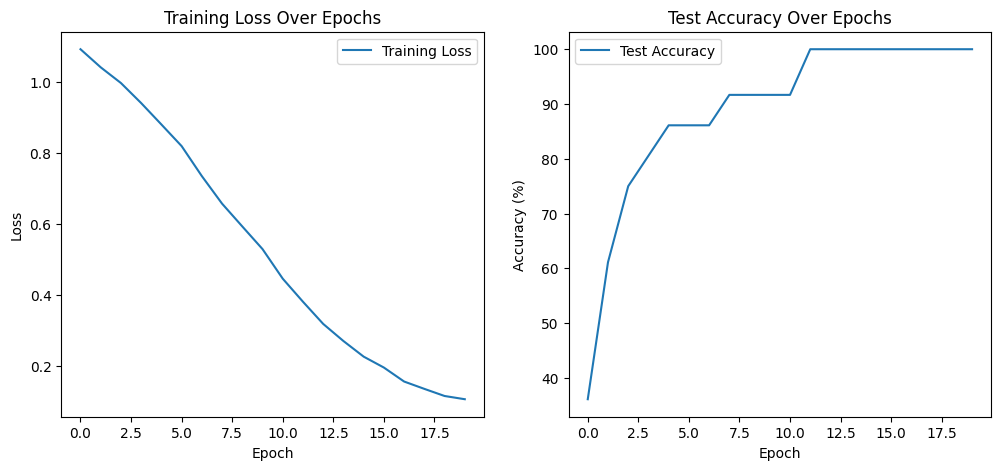

In [51]:
# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()

plt.show()

In [52]:
# 데이터와 타겟 분리
X = data.drop('Wine', axis=1).values
y = data['Wine'].values

In [53]:
# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [54]:
data_array = np.hstack((X, y.reshape(-1, 1)))

In [55]:
data_array.shape

(178, 14)

In [56]:
# Split sequences function
# car_evaluation_pytorch의 CNN 방식과 동일하게 n_steps 길이의 묶음을 만든다.
# wine 데이터는 시계열 데이터는 아니므로, 이 CNN 구조는 분류 모델 구조 연습용으로 해석하는 것이 적절하다.
def split_sequences(sequences, n_steps):
    X, y = list(), list()
    for i in range(len(sequences)):
        end_ix = i + n_steps
        if end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Apply sequence transformation
n_steps = 5
X, y = split_sequences(data_array, n_steps)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)


In [57]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((139, 5, 13), (139,), (35, 5, 13), (35,))

In [58]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.int64)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [59]:
# Define the 1D CNN model
class WineCNN(nn.Module):
    def __init__(self):
        super(WineCNN, self).__init__()
        self.conv1 = nn.Conv1d(13, 16, kernel_size=3, padding=1)  # wine 입력 채널: 13개 특성
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 5, 64)  # n_steps=5이므로 Conv1d 이후 길이 5 유지
        self.fc2 = nn.Linear(64, 3)       # wine 클래스 3개

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)                   # CrossEntropyLoss 사용 시 softmax를 따로 적용하지 않음
        return x


In [60]:
# Initialize the model, loss function, and optimizer
model = WineCNN()


In [61]:
# Print the summary of the model
# DataLoader 입력: (batch_size, n_steps, features) = (batch, 5, 13)
# Conv1d 입력: (batch_size, channels, sequence_length) = (batch, 13, 5)
if summary is not None:
    summary(model, input_size=(13, 5))
else:
    print(model)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1                [-1, 16, 5]             640
            Conv1d-2                [-1, 32, 5]           1,568
            Linear-3                   [-1, 64]          10,304
            Linear-4                    [-1, 3]             195
Total params: 12,707
Trainable params: 12,707
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.05
Estimated Total Size (MB): 0.05
----------------------------------------------------------------


In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Variables to store loss and accuracy
train_losses = []
test_accuracies = []

Epoch 1/20, Loss: 1.0615, Accuracy: 57.14%
Epoch 2/20, Loss: 0.9726, Accuracy: 80.00%
Epoch 3/20, Loss: 0.8441, Accuracy: 97.14%
Epoch 4/20, Loss: 0.6458, Accuracy: 97.14%
Epoch 5/20, Loss: 0.4262, Accuracy: 97.14%
Epoch 6/20, Loss: 0.2354, Accuracy: 97.14%
Epoch 7/20, Loss: 0.1130, Accuracy: 97.14%
Epoch 8/20, Loss: 0.0480, Accuracy: 94.29%
Epoch 9/20, Loss: 0.0257, Accuracy: 94.29%
Epoch 10/20, Loss: 0.0150, Accuracy: 94.29%
Epoch 11/20, Loss: 0.0114, Accuracy: 94.29%
Epoch 12/20, Loss: 0.0070, Accuracy: 94.29%
Epoch 13/20, Loss: 0.0050, Accuracy: 94.29%
Epoch 14/20, Loss: 0.0038, Accuracy: 94.29%
Epoch 15/20, Loss: 0.0033, Accuracy: 94.29%
Epoch 16/20, Loss: 0.0027, Accuracy: 94.29%
Epoch 17/20, Loss: 0.0022, Accuracy: 94.29%
Epoch 18/20, Loss: 0.0032, Accuracy: 94.29%
Epoch 19/20, Loss: 0.0018, Accuracy: 94.29%
Epoch 20/20, Loss: 0.0015, Accuracy: 94.29%
Training complete.
Confusion Matrix:
[[11  0  0]
 [ 2 13  0]
 [ 0  0  9]]
F1 Score: 0.94
Precision: 0.95
Recall: 0.94
Specificity

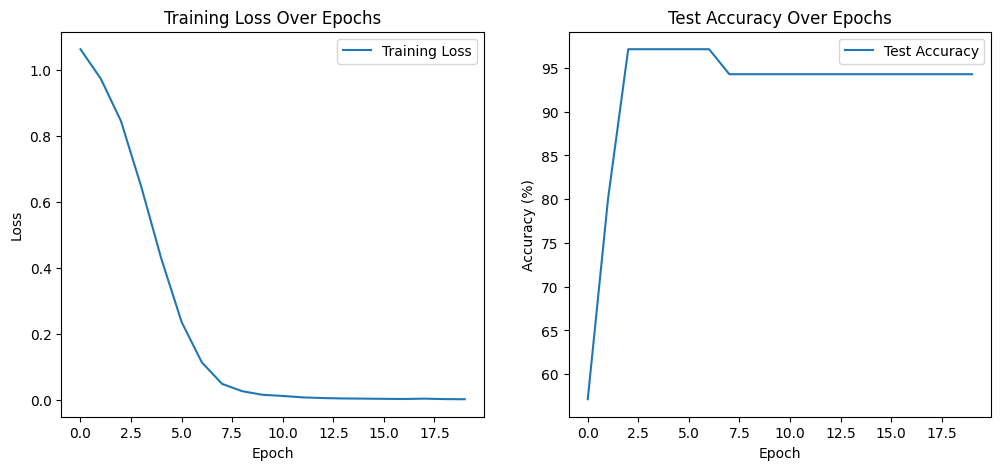

In [63]:
# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        inputs = inputs.permute(0, 2, 1)  # Change shape to (batch_size, channels, sequence_length)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss over an epoch
    train_losses.append(running_loss / len(train_dataloader))

    # Evaluate on test data
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.permute(0, 2, 1)  # Change shape to (batch_size, channels, sequence_length)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Calculate metrics
conf_matrix = confusion_matrix(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)

# Calculate specificity for each class
specificity = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp) if (tn + fp) != 0 else 0)

# Print metrics
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'F1 Score: {f1:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Specificity: {np.mean(specificity):.2f}')

# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()

plt.show()